In [1]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
import pickle
import copy
from data_evaluation_API import data_evaluation as eval
from Influxdb_API.Influxdb_API import ClientInfluxdb
%matplotlib inline

## 1. 从Influxdb_API获取数据
+ 以1K0V多联机0号室内机的温度为例

In [2]:
db_name='moserver'
params={
    'measurement_name':'modata',
    'start_time': pd.to_datetime('2022-11-01 00:00:00'),
    'end_time': pd.to_datetime('2022-12-01 00:00:00'),
    'field_list': ['roomTemp'],
    'tag_dict': {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client = ClientInfluxdb(db_name=db_name) 
df = db_client.read_influxdb(**params)
print('data acquired')

data acquired


## 2. 设定相关处理参数，对数据进行必要的前处理
+ 将从数据库中获取的数据的字符类型转换为float类型
+ 进行重采样

In [3]:
params_process={
    'rsp_time': pd.Timedelta('15 min'),
    'rsp_num': 4, # 4 times per hour
    'step': 4*24*3,  # to calculate missing rate, step=4/h*24h/day*3day表示计算每个时刻向前回溯三天的数据缺失率
    'imputation_time_delta': pd.Timedelta('6 hours') # 连续缺失超过imputation_time_delta的数据将不会被插补
}
# str -> np.float64
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
# resampling data, rsp_time=15min
df = eval.resampling(df, params_process['rsp_time'])
print(df)

                      roomTemp
2022-11-02 08:00:00  30.000000
2022-11-02 08:15:00  29.990000
2022-11-02 08:30:00  29.941667
2022-11-02 08:45:00  29.900000
2022-11-02 09:00:00  29.900000
...                        ...
2022-11-30 20:45:00  28.700000
2022-11-30 21:00:00  28.700000
2022-11-30 21:15:00  28.700000
2022-11-30 21:30:00  28.700000
2022-11-30 21:45:00  28.625000

[2744 rows x 1 columns]


## 3. 计算原始数据/去除异常值数据/数据插补后的数据缺失率
+ params_process['step'] = 4/h * 24h/day * 3day 表示计算每个时刻向前回溯三天的数据缺失率

3.1 计算原始数据的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.24580903790087477
roomTemp the closest optimal moment to the present:  2022-11-30 21:45:00


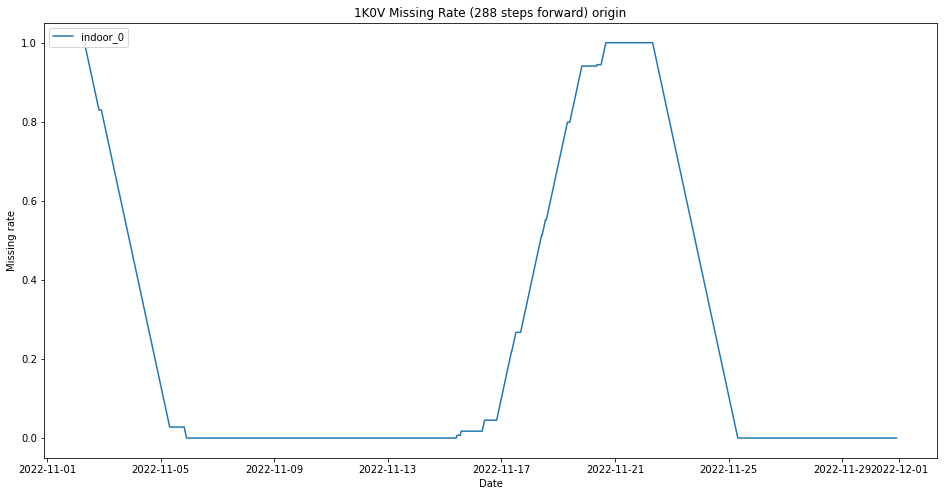

In [4]:
missing_rate = eval.cal_missing_rate(df, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate.index, missing_rate, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'origin')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()


3.2 计算去除异常值后的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.24580903790087477
roomTemp the closest optimal moment to the present:  2022-11-30 21:45:00


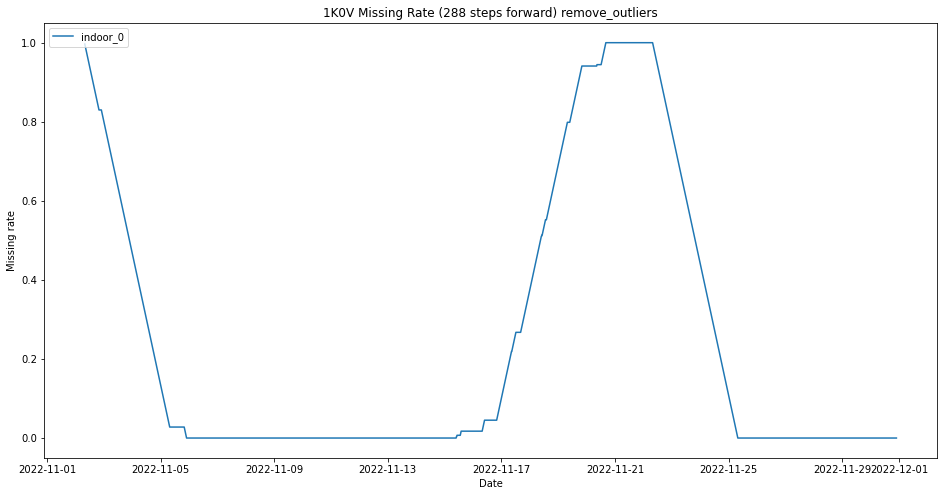

In [5]:
df_process = eval.remove_outliers(df)
missing_rate_process = eval.cal_missing_rate(df_process, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate_process.index, missing_rate_process, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'remove_outliers')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

3.3 计算数据插补后的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.23305393586005785
roomTemp the closest optimal moment to the present:  2022-11-30 21:45:00


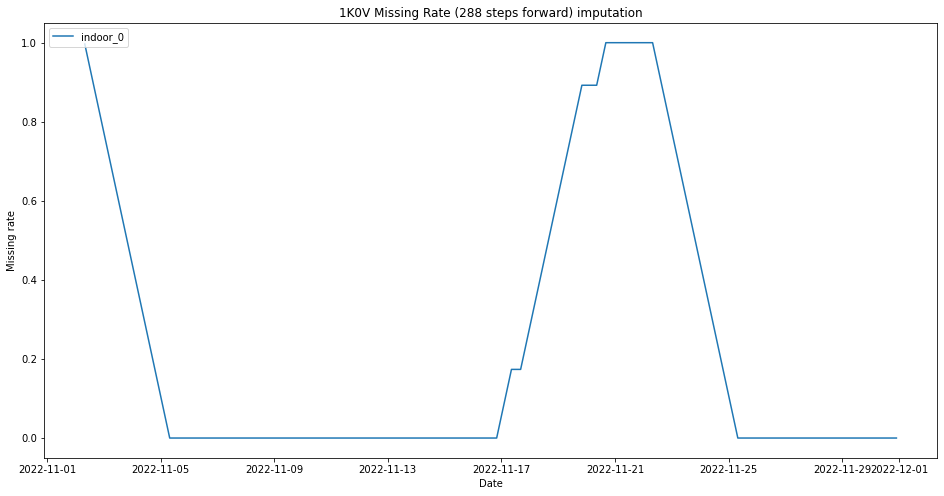

In [6]:
df_new = eval.linear_imputation(df_process, params_process['imputation_time_delta'], params_process['rsp_time'])
missing_rate_new = eval.cal_missing_rate(df_new, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate_new.index, missing_rate_new, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'imputation')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()